# Configuration

In [1]:
import os 

if True ^ os.getcwd().endswith('hte-and-targeting'):
    os.chdir('..')

In [2]:
import pandas as pd 
import numpy as np

In [3]:
from scipy.stats import norm, invgamma
# estimators
# from econml.grf import CausalForest
from statsmodels.regression.linear_model import OLS
from sklearn.linear_model import LinearRegression, Lasso

# import causal forest

from scipy.integrate import quad 
from scipy.stats import ks_2samp

In [4]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

In [5]:
from core.variables import * 
from core.dgp import *

import core.continuous_segment as cs 

# DGP

$$
\begin{aligned}
Y_i & = c + \alpha'X_i T_i + \beta' X_i + \epsilon_i \\ 
\end{aligned}
$$

In [58]:
dgp_params = {
    'te_arr': np.array([1, 1.1]), 
    'beta': 0, 'const': 0, 
    'noise_std': 1
}

dgp = ContinuousSegments(**dgp_params)

In [59]:
X_train, T_train, Y_train = dgp.sample(5000)
X_test, T_test, Y_test = dgp.sample(1000)

# Demand Model

In [60]:
clr = cs.CorrectLinearRegression(dgp.treatment_space, fit_x=False, fit_intercept=True).fit(X_train, T_train, Y_train)
segment_model = cs.SegmentModel(dgp.treatment_space, threshold=0).fit(X_train, T_train, Y_train)
cf1 = cs.CausalForest(n_estimators=100, max_depth=1).fit(X_train, T_train, Y_train)
cf10 = cs.CausalForest(n_estimators=100, max_depth=10).fit(X_train, T_train, Y_train)

In [61]:
def evaluate_demand_model(demand_model, X: np.ndarray, T: np.ndarray, Y: np.ndarray):
    y_pred = demand_model.predict(X, T)

    rmse = np.sqrt(np.mean((y_pred - Y) ** 2))
    r2 = 1 - np.sum((Y - y_pred) ** 2) / np.sum((Y - np.mean(Y)) ** 2)
    mape = np.mean(np.abs((Y - y_pred) / Y))

    return {
        'rmse': rmse, 
        'r2': r2, 
        'mape': mape
    }

print('In sample performance: \n', pd.DataFrame({
    'correct_model': evaluate_demand_model(clr, X_train, T_train, Y_train),
    'segment_model': evaluate_demand_model(segment_model, X_train, T_train, Y_train),
    'causal_forest_1': evaluate_demand_model(cf1, X_train, T_train, Y_train), 
    'causal_forest_10': evaluate_demand_model(cf10, X_train, T_train, Y_train)
}))

print('\nOut of sample performance: \n', pd.DataFrame({
    'correct_model': evaluate_demand_model(clr, X_test, T_test, Y_test),
    'segment_model': evaluate_demand_model(segment_model, X_test, T_test, Y_test),
    'causal_forest_1': evaluate_demand_model(cf1, X_test, T_test, Y_test), 
    'causal_forest_10': evaluate_demand_model(cf10, X_test, T_test, Y_test)
}))

In sample performance: 
       correct_model  segment_model  causal_forest_1  causal_forest_10
rmse       1.004935       1.194908         1.455429          1.433740
r2         0.538353       0.347315         0.031686          0.060330
mape      17.632513      14.012475         1.499558          4.753511

Out of sample performance: 
       correct_model  segment_model  causal_forest_1  causal_forest_10
rmse       0.960235       1.146342         1.400427          1.401946
r2         0.546022       0.352995         0.034394          0.032298
mape       2.856928       5.581237         1.088023          1.210984


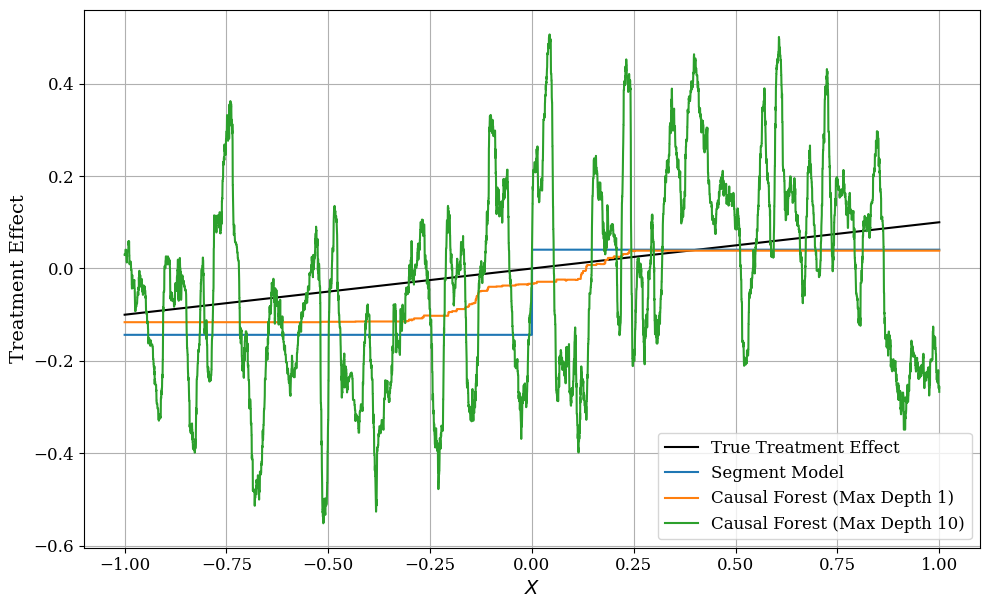

In [ ]:
x_space = np.linspace(-1, 1, 10000)
true_te = x_space * (dgp.te_arr[1] - dgp.te_arr[0])
segment_te = segment_model.predict_effect(x_space)
cf1_te = cf1.predict_effect(x_space[:, np.newaxis])
cf10_te = cf10.predict_effect(x_space[:, np.newaxis])

fig, ax = plt.subplots(figsize=(10, 6.18))

ax.plot(x_space, true_te, color='k', label='True Treatment Effect')
ax.plot(x_space, segment_te, color='C0', label='Segment Model')
ax.plot(x_space, cf1_te, color='C1', label='Causal Forest (Max Depth 1)')
ax.plot(x_space, cf10_te, color='C2', label='Causal Forest (Max Depth 10)')

ax.legend(fontsize=legend_label_size)
ax.set_xlabel(r'$X$', fontsize=axis_label_size)
ax.set_ylabel(r'Treatment Effect $\tau_2 - \tau_1$', fontsize=axis_label_size)
ax.tick_params(labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()


# Optimization

In [63]:
plugin_decision, plugin_val_est = cs.optimize(clr, X_test, dgp.treatment_space)
true_plugin_val = cs.obj_func(dgp, X_test, plugin_decision)

print('\nCorrect Demand Model')
print(f'Plugin value estimate: {plugin_val_est:.4f}, True plugin value: {true_plugin_val:.4f}')

plugin_decision, plugin_val_est = cs.optimize(segment_model, X_test, dgp.treatment_space)
true_plugin_val = cs.obj_func(dgp, X_test, plugin_decision)

print('\nSegment Demand Model')
print(f'Plugin value estimate: {plugin_val_est:.4f}, True plugin value: {true_plugin_val:.4f}')

plugin_decision, plugin_val_est = cs.optimize(cf1, X_test, dgp.treatment_space)
true_plugin_val = cs.obj_func(dgp, X_test, plugin_decision)

print('\nCausal Forest (Max Depth 1) Model')
print(f'Plugin value estimate: {plugin_val_est:.4f}, True plugin value: {true_plugin_val:.4f}')

plugin_decision, plugin_val_est = cs.optimize(cf10, X_test, dgp.treatment_space)
true_plugin_val = cs.obj_func(dgp, X_test, plugin_decision)

print('\nCausal Forest (Max Depth 10) Model')
print(f'Plugin value estimate: {plugin_val_est:.4f}, True plugin value: {true_plugin_val:.4f}')


Correct Demand Model
Plugin value estimate: 0.0466, True plugin value: 0.0607

Segment Demand Model
Plugin value estimate: 0.0557, True plugin value: 0.0607

Causal Forest (Max Depth 1) Model
Plugin value estimate: 0.0168, True plugin value: 0.0604

Causal Forest (Max Depth 10) Model
Plugin value estimate: 0.0907, True plugin value: 0.0389


In [64]:
del dgp, clr, X_train, T_train, Y_train, X_test, T_test, Y_test
del plugin_decision, plugin_val_est, true_plugin_val


# Winner's Curse

## Correct Model

In [65]:
dgp_params = {
    'te_arr': np.array([1, 1.1]), 
    'beta': 0, 'const': 0, 
    'noise_std': 1
}

data_params = {'sample_size': 500, 'n_customers': 100}

experiment_params = {
    'n_experiments': 5000, 
    'dm_info': {
        'model': cs.CorrectLinearRegression, 
        'params': {'fit_x': False, 'fit_intercept': False}, 
    },
}

estimators_dict = {}

result_records = cs.repeated_experiments(
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    n_jobs=-1, verbose=True
)

wc_measures_dict = cs.calculate_winners_curse_measures(
    result_records=result_records, 
    estimators_dict=estimators_dict, data_params=data_params
)

print(f"Average Estimated Targeting Value: {wc_measures_dict['nc_val_est_avg']:.4f} ({wc_measures_dict['nc_val_est_se']:.4f})")
print(f"Average True Targeting Value: {wc_measures_dict['nc_val_true_avg']:.4f} ({wc_measures_dict['nc_val_true_se']:.4f})")
print(f"Average Winner's Curse: {wc_measures_dict['nc_wc_avg']:.4f} ({wc_measures_dict['nc_wc_se']:.4f})")

Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s


Average Estimated Targeting Value: 0.0459 (0.0050)
Average True Targeting Value: 0.0308 (0.0049)
Average Winner's Curse: 0.0151 (0.0015)


[Parallel(n_jobs=-1)]: Done 3835 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    0.3s finished


## Segment Model

In [66]:
dgp_params = {
    'te_arr': np.array([1, 1.1]), 
    'beta': 0, 'const': 0, 
    'noise_std': 1
}

data_params = {'sample_size': 500, 'seed': None, 'n_customers': 100}

experiment_params = {
    'n_experiments': 5000, 
    'dm_info': {
        'model': cs.SegmentModel, 
        'params': {'threshold': 0}, 
    },
}

estimators_dict = {}


result_records = cs.repeated_experiments(
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    n_jobs=-1, verbose=True
)

wc_measures_dict = cs.calculate_winners_curse_measures(
    result_records=result_records, 
    estimators_dict=estimators_dict, data_params=data_params
)

print(f"Average Estimated Targeting Value: {wc_measures_dict['nc_val_est_avg']:.4f} ({wc_measures_dict['nc_val_est_se']:.4f})")
print(f"Average True Targeting Value: {wc_measures_dict['nc_val_true_avg']:.4f} ({wc_measures_dict['nc_val_true_se']:.4f})")
print(f"Average Winner's Curse: {wc_measures_dict['nc_wc_avg']:.4f} ({wc_measures_dict['nc_wc_se']:.4f})")

Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s


Average Estimated Targeting Value: 0.0691 (0.0048)
Average True Targeting Value: 0.0180 (0.0049)
Average Winner's Curse: 0.0511 (0.0041)


[Parallel(n_jobs=-1)]: Done 3545 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    0.5s finished


## Causal Forest

In [67]:
dgp_params = {
    'te_arr': np.array([1, 1.1]), 
    'beta': 0, 'const': 0, 
    'noise_std': 1
}

data_params = {'sample_size': 500, 'seed': None, 'n_customers': 100}

experiment_params = {
    'n_experiments': 5000, 
    'dm_info': {
        'model': cs.CausalForest, 
        'params': {'max_depth': 1, 'n_estimators': 100}, 
    },
}

estimators_dict = {}


result_records = cs.repeated_experiments(
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    n_jobs=-1, verbose=True
)

wc_measures_dict = cs.calculate_winners_curse_measures(
    result_records=result_records, 
    estimators_dict=estimators_dict, data_params=data_params
)

print(f"Average Estimated Targeting Value: {wc_measures_dict['nc_val_est_avg']:.4f} ({wc_measures_dict['nc_val_est_se']:.4f})")
print(f"Average True Targeting Value: {wc_measures_dict['nc_val_true_avg']:.4f} ({wc_measures_dict['nc_val_true_se']:.4f})")
print(f"Average Winner's Curse: {wc_measures_dict['nc_wc_avg']:.4f} ({wc_measures_dict['nc_wc_se']:.4f})")

Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 208 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 708 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 1408 tasks      | elapsed:    7.1s
[Parallel(n_jobs=-1)]: Done 2308 tasks      | elapsed:   11.5s
[Parallel(n_jobs=-1)]: Done 3408 tasks      | elapsed:   17.0s
[Parallel(n_jobs=-1)]: Done 4708 tasks      | elapsed:   23.5s


Average Estimated Targeting Value: 0.0624 (0.0028)
Average True Targeting Value: 0.0172 (0.0049)
Average Winner's Curse: 0.0452 (0.0055)


[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:   24.8s finished


In [68]:
dgp_params = {
    'te_arr': np.array([1, 1.1]), 
    'beta': 0, 'const': 0, 
    'noise_std': 1
}

data_params = {'sample_size': 500, 'seed': None, 'n_customers': 100}

experiment_params = {
    'n_experiments': 5000, 
    'dm_info': {
        'model': cs.CausalForest, 
        'params': {'max_depth': 10, 'n_estimators': 100}, 
    },
}

estimators_dict = {}


result_records = cs.repeated_experiments(
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    n_jobs=-1, verbose=True
)

wc_measures_dict = cs.calculate_winners_curse_measures(
    result_records=result_records, 
    estimators_dict=estimators_dict, data_params=data_params
)

print(f"Average Estimated Targeting Value: {wc_measures_dict['nc_val_est_avg']:.4f} ({wc_measures_dict['nc_val_est_se']:.4f})")
print(f"Average True Targeting Value: {wc_measures_dict['nc_val_true_avg']:.4f} ({wc_measures_dict['nc_val_true_se']:.4f})")
print(f"Average Winner's Curse: {wc_measures_dict['nc_wc_avg']:.4f} ({wc_measures_dict['nc_wc_se']:.4f})")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done 208 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 708 tasks      | elapsed:    4.2s
[Parallel(n_jobs=-1)]: Done 1408 tasks      | elapsed:    8.4s
[Parallel(n_jobs=-1)]: Done 2308 tasks      | elapsed:   13.7s
[Parallel(n_jobs=-1)]: Done 3408 tasks      | elapsed:   20.1s
[Parallel(n_jobs=-1)]: Done 4708 tasks      | elapsed:   27.7s


Average Estimated Targeting Value: 0.1195 (0.0025)
Average True Targeting Value: 0.0141 (0.0048)
Average Winner's Curse: 0.1054 (0.0052)


[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:   29.3s finished


# Estimating winner's curse

In [69]:
dgp = ContinuousSegments(**dgp_params)
X, T, Y = dgp.sample(data_params['sample_size'], seed=1)
targ_customers = dgp.sample_individuals(data_params['n_customers'], seed=1)

## Standard bootstrap

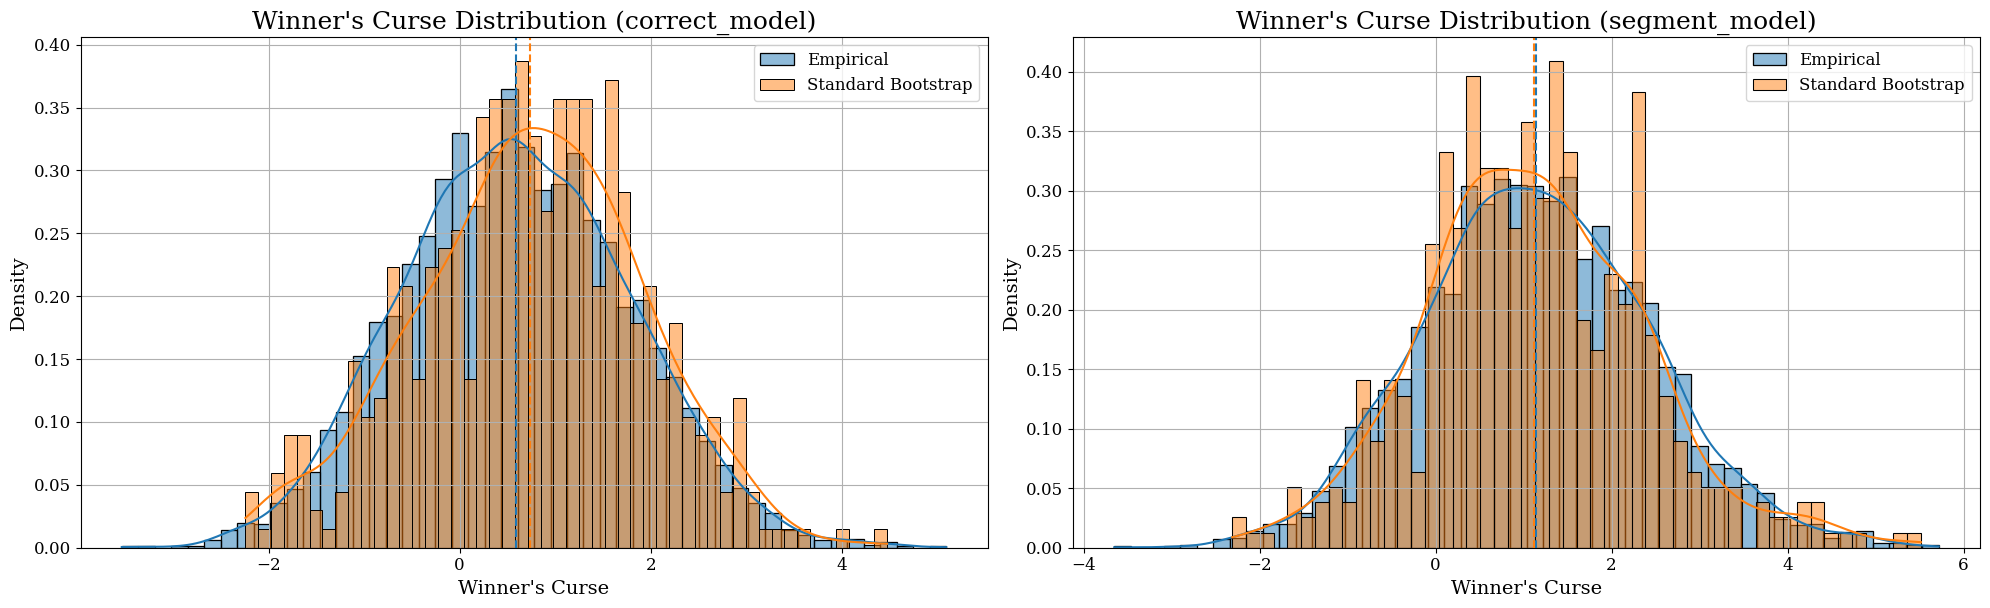

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

for idx, demand_model in enumerate(cs.demand_model_dict.keys()):
    boot_wc_dstn_arr = cs.get_wc_boot_dstn(
        X=X, T=T, Y=Y,
        targ_customers=targ_customers, treatment_space=dgp.treatment_space,
        n_bootstraps=500, demand_model=demand_model, 
        n_jobs=-1, verbose=False
    )

    # empirical winner's curse
    sns.histplot(wc_result_dict[demand_model]['emp_wc_dstn_arr'], bins=50, kde=True, stat='density', color='C0', label='Empirical', ax=axes[idx])
    axes[idx].axvline(np.nanmean(wc_result_dict[demand_model]['emp_wc_dstn_arr']), color='C0', linestyle='--')

    # bootstrap winner's curse
    sns.histplot(boot_wc_dstn_arr, bins=50, kde=True, stat='density', color='C1', label='Standard Bootstrap', ax=axes[idx])
    axes[idx].axvline(np.nanmean(boot_wc_dstn_arr), color='C1', linestyle='--')

    axes[idx].set_title(f'Winner\'s Curse Distribution ({demand_model})', fontsize=title_size)
    axes[idx].set_xlabel('Winner\'s Curse', fontsize=axis_label_size)
    axes[idx].set_ylabel('Density', fontsize=axis_label_size)
    axes[idx].tick_params(labelsize=tick_label_size)
    axes[idx].legend(fontsize=legend_label_size)

    axes[idx].grid()

plt.tight_layout()
plt.show()

## m-out-of-n bootstrap

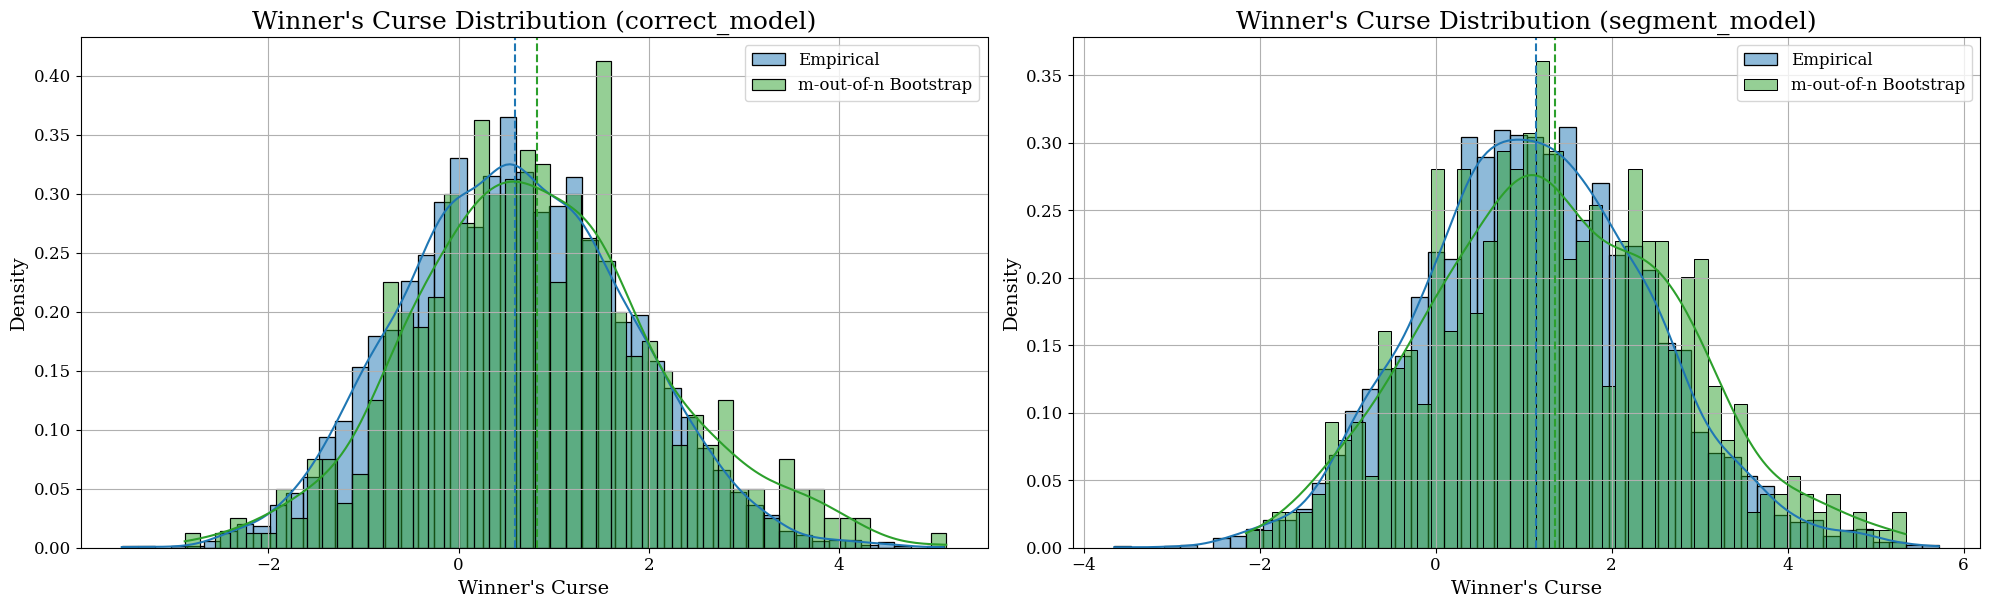

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

for idx, demand_model in enumerate(cs.demand_model_dict.keys()):
    mn_boot_wc_dstn_arr = cs.get_wc_m_out_of_n_boot_dstn(
        X=X, T=T, Y=Y,
        targ_customers=targ_customers, treatment_space=dgp.treatment_space,
        n_bootstraps=500, power=0.95, 
        demand_model=demand_model, 
        n_jobs=-1, verbose=False
    )

    # empirical winner's curse
    sns.histplot(wc_result_dict[demand_model]['emp_wc_dstn_arr'], bins=50, kde=True, stat='density', color='C0', label='Empirical', ax=axes[idx])
    axes[idx].axvline(np.nanmean(wc_result_dict[demand_model]['emp_wc_dstn_arr']), color='C0', linestyle='--')

    # bootstrap winner's curse
    sns.histplot(mn_boot_wc_dstn_arr, bins=50, kde=True, stat='density', color='C2', label='m-out-of-n Bootstrap', ax=axes[idx])
    axes[idx].axvline(np.nanmean(mn_boot_wc_dstn_arr), color='C2', linestyle='--')

    axes[idx].set_title(f'Winner\'s Curse Distribution ({demand_model})', fontsize=title_size)
    axes[idx].set_xlabel('Winner\'s Curse', fontsize=axis_label_size)
    axes[idx].set_ylabel('Density', fontsize=axis_label_size)
    axes[idx].tick_params(labelsize=tick_label_size)
    axes[idx].legend(fontsize=legend_label_size)

    axes[idx].grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap 

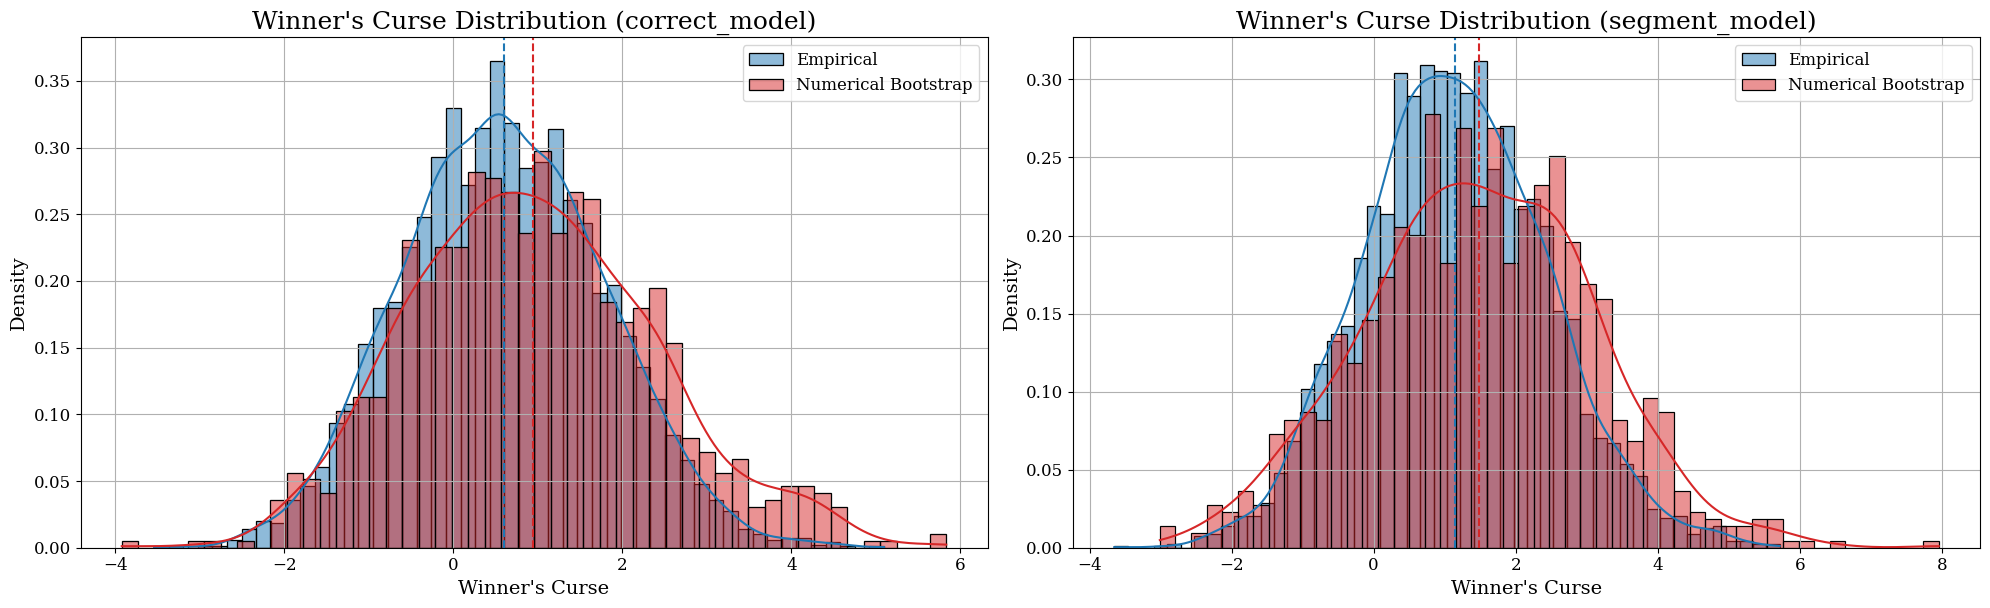

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

for idx, demand_model in enumerate(cs.demand_model_dict.keys()):
    num_boot_wc_dstn_arr = cs.get_wc_num_boot_dstn(
        X=X, T=T, Y=Y,
        targ_customers=targ_customers, treatment_space=dgp.treatment_space,
        n_bootstraps=1000, power=-0.45, 
        demand_model=demand_model, 
        n_jobs=-1, verbose=False
    )

    # empirical winner's curse
    sns.histplot(wc_result_dict[demand_model]['emp_wc_dstn_arr'], bins=50, kde=True, stat='density', color='C0', label='Empirical', ax=axes[idx])
    axes[idx].axvline(np.nanmean(wc_result_dict[demand_model]['emp_wc_dstn_arr']), color='C0', linestyle='--')
    
    # bootstrap winner's curse
    sns.histplot(num_boot_wc_dstn_arr, bins=50, kde=True, stat='density', color='C3', label='Numerical Bootstrap', ax=axes[idx])
    axes[idx].axvline(np.nanmean(num_boot_wc_dstn_arr), color='C3', linestyle='--')

    axes[idx].set_title(f'Winner\'s Curse Distribution ({demand_model})', fontsize=title_size)
    axes[idx].set_xlabel('Winner\'s Curse', fontsize=axis_label_size)
    axes[idx].set_ylabel('Density', fontsize=axis_label_size)
    axes[idx].tick_params(labelsize=tick_label_size)
    axes[idx].legend(fontsize=legend_label_size)

    axes[idx].grid()

plt.tight_layout()
plt.show()

# Bias Correction

## Correct Model

In [6]:
dgp_params = {
    'te_arr': np.array([1, 1.1]), 
    'beta': 0, 'const': 0, 
    'noise_std': 1
}

data_params = {'sample_size': 500, 'n_customers': 100}

experiment_params = {
    'n_experiments': 5000, 
    'dm_info': {
        'model': cs.CorrectLinearRegression, 
        'params': {'fit_x': False, 'fit_intercept': False}, 
    },
}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': cs.bootstrap_correction_estimate,
        'params': {'bootstrap_method': 'standard', 'n_bootstraps': 500, 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap'
    }, 
    'mn_bootstrap': {
        'estimator': cs.bootstrap_correction_estimate,
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 500, 'power': 0.97, 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap'
    }, 
    'num_bootstrap': {
        'estimator': cs.bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 500, 'power': -0.47, 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap'
    }
}

result_records = cs.repeated_experiments(
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    n_jobs=-1, verbose=True
)

wc_measures_dict = cs.calculate_winners_curse_measures(
    result_records=result_records, 
    estimators_dict=estimators_dict, data_params=data_params
)

Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    5.6s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   12.0s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   20.7s
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:   32.0s
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:   45.3s
[Parallel(n_jobs=-1)]: Done 2386 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 3136 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 4936 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:  2.1min finished


In [7]:
wc_dict = {}
delta_tau = dgp_params['te_arr'][1] - dgp_params['te_arr'][0]
for estimator in ['nc'] + list(estimators_dict.keys()):
    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'

    wc_dict.update({
        display_name: {
            "Avg. Winner's Curse (%)": 100 * wc_measures_dict[f'{estimator}_wc_avg'] / delta_tau, 
            "S.E. Winner's Curse (%)": 100 * wc_measures_dict[f'{estimator}_wc_se'] / delta_tau,
            # 'wc_pct_avg': wc_measures_dict[f'{estimator}_wc_pct_avg'], 'wc_pct_se': wc_measures_dict[f'{estimator}_wc_pct_se'],
            # 'wc_rmse': wc_measures_dict[f'{estimator}_wc_rmse']
            "Median Winner's Curse (%)": 100 * np.nanmedian(wc_measures_dict[f'{estimator}_wc_arr']) / delta_tau,
            "Correct Decision Rate (%)": 100 * wc_measures_dict[f'{estimator}_correct_decision_rate']
        }
    })

wc_df = pd.DataFrame.from_dict(wc_dict, orient='index')
del wc_dict 

print("Overestimated Purchase Probability Lift: ")
wc_df.round(2)

Overestimated Purchase Probability Lift: 


,Avg. Winner's Curse (%),S.E. Winner's Curse (%),Median Winner's Curse (%),Correct Decision Rate (%)
No Correction,15.10,1.46,11.78,86.02
Standard Bootstrap,0.06,1.72,1.25,86.02
m-out-of-n Bootstrap,-2.73,1.75,-1.74,86.02
Numerical Bootstrap,-2.99,1.79,-0.77,86.02


## Segment Model

In [8]:
dgp_params = {
    'te_arr': np.array([1, 1.1]), 
    'beta': 0, 'const': 0, 
    'noise_std': 1
}

data_params = {'sample_size': 500, 'n_customers': 100}

experiment_params = {
    'n_experiments': 5000, 
    'dm_info': {
        'model': cs.SegmentModel, 
        'params': {'threshold': 0}, 
    },
}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': cs.bootstrap_correction_estimate,
        'params': {'bootstrap_method': 'standard', 'n_bootstraps': 500, 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap'
    }, 
    'mn_bootstrap': {
        'estimator': cs.bootstrap_correction_estimate,
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 500, 'power': 0.95, 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap'
    }, 
    'num_bootstrap': {
        'estimator': cs.bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 500, 'power': -0.45, 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap'
    }
}

result_records = cs.repeated_experiments(
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    n_jobs=-1, verbose=True
)

wc_measures_dict = cs.calculate_winners_curse_measures(
    result_records=result_records, 
    estimators_dict=estimators_dict, data_params=data_params
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   18.1s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   51.8s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:  3.7min
[Parallel(n_jobs=-1)]: Done 2386 tasks      | elapsed:  5.1min
[Parallel(n_jobs=-1)]: Done 3136 tasks      | elapsed:  6.7min
[Parallel(n_jobs=-1)]: Done 3986 tasks      | elapsed:  8.6min
[Parallel(n_jobs=-1)]: Done 4936 tasks      | elapsed: 10.6min
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed: 10.7min finished


In [9]:
wc_dict = {}
delta_tau = dgp_params['te_arr'][1] - dgp_params['te_arr'][0]
for estimator in ['nc'] + list(estimators_dict.keys()):
    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'

    wc_dict.update({
        display_name: {
            "Avg. Winner's Curse (%)": 100 * wc_measures_dict[f'{estimator}_wc_avg'] / delta_tau, 
            "S.E. Winner's Curse (%)": 100 * wc_measures_dict[f'{estimator}_wc_se'] / delta_tau,
            # 'wc_pct_avg': wc_measures_dict[f'{estimator}_wc_pct_avg'], 'wc_pct_se': wc_measures_dict[f'{estimator}_wc_pct_se'],
            # 'wc_rmse': wc_measures_dict[f'{estimator}_wc_rmse']
            "Median Winner's Curse (%)": 100 * np.nanmedian(wc_measures_dict[f'{estimator}_wc_arr']) / delta_tau,
            "Correct Decision Rate (%)": 100 * wc_measures_dict[f'{estimator}_correct_decision_rate']
        }
    })

wc_df = pd.DataFrame.from_dict(wc_dict, orient='index')
del wc_dict 

print("Overestimated Purchase Probability Lift: ")
wc_df.round(2)

Overestimated Purchase Probability Lift: 


,Avg. Winner's Curse (%),S.E. Winner's Curse (%),Median Winner's Curse (%),Correct Decision Rate (%)
No Correction,51.09,4.09,51.17,69.99
Standard Bootstrap,11.63,4.31,11.97,69.99
m-out-of-n Bootstrap,1.01,4.32,0.71,69.99
Numerical Bootstrap,-2.70,4.41,-2.56,69.99


## Causal Forest

In [10]:
dgp_params = {
    'te_arr': np.array([1, 1.1]), 
    'beta': 0, 'const': 0, 
    'noise_std': 1
}

data_params = {'sample_size': 500, 'n_customers': 100}

experiment_params = {
    'n_experiments': 500, 
    'dm_info': {
        'model': cs.CausalForest, 
        'params': {'max_depth': 1, 'n_estimators': 100}, 
    },
}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': cs.bootstrap_correction_estimate,
        'params': {'bootstrap_method': 'standard', 'n_bootstraps': 200, 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap'
    }, 
    'mn_bootstrap': {
        'estimator': cs.bootstrap_correction_estimate,
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 200, 'power': 0.97, 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap'
    }, 
    'num_bootstrap': {
        'estimator': cs.bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 200, 'power': -0.47, 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap'
    }
}

result_records = cs.repeated_experiments(
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    n_jobs=-1, verbose=True
)

wc_measures_dict = cs.calculate_winners_curse_measures(
    result_records=result_records, 
    estimators_dict=estimators_dict, data_params=data_params
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  9.5min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 24.7min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 30.0min finished


In [11]:
wc_dict = {}
delta_tau = dgp_params['te_arr'][1] - dgp_params['te_arr'][0]
for estimator in ['nc'] + list(estimators_dict.keys()):
    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'

    wc_dict.update({
        display_name: {
            "Avg. Winner's Curse (%)": 100 * wc_measures_dict[f'{estimator}_wc_avg'] / delta_tau, 
            "S.E. Winner's Curse (%)": 100 * wc_measures_dict[f'{estimator}_wc_se'] / delta_tau,
            # 'wc_pct_avg': wc_measures_dict[f'{estimator}_wc_pct_avg'], 'wc_pct_se': wc_measures_dict[f'{estimator}_wc_pct_se'],
            # 'wc_rmse': wc_measures_dict[f'{estimator}_wc_rmse']
            "Median Winner's Curse (%)": 100 * np.nanmedian(wc_measures_dict[f'{estimator}_wc_arr']) / delta_tau,
            "Correct Decision Rate (%)": 100 * wc_measures_dict[f'{estimator}_correct_decision_rate']
        }
    })

wc_df = pd.DataFrame.from_dict(wc_dict, orient='index')
del wc_dict 

print("Overestimated Purchase Probability Lift: ")
wc_df.round(2)

Overestimated Purchase Probability Lift: 


,Avg. Winner's Curse (%),S.E. Winner's Curse (%),Median Winner's Curse (%),Correct Decision Rate (%)
No Correction,39.37,5.52,36.98,65.93
Standard Bootstrap,-0.74,5.64,-8.93,65.25
m-out-of-n Bootstrap,-4.94,5.63,-10.13,65.91
Numerical Bootstrap,-8.44,5.66,-15.88,66.50


In [ ]:
dgp_params = {
    'te_arr': np.array([1, 1.1]), 
    'beta': 0, 'const': 0, 
    'noise_std': 1
}

data_params = {'sample_size': 500, 'n_customers': 100}

experiment_params = {
    'n_experiments': 500, 
    'dm_info': {
        'model': cs.CausalForest, 
        'params': {'max_depth': 10, 'n_estimators': 100}, 
    },
}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': cs.bootstrap_correction_estimate,
        'params': {'bootstrap_method': 'standard', 'n_bootstraps': 200, 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap'
    }, 
    'mn_bootstrap': {
        'estimator': cs.bootstrap_correction_estimate,
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 200, 'power': 0.95, 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap'
    }, 
    'num_bootstrap': {
        'estimator': cs.bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 200, 'power': -0.45, 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap'
    }
}

result_records = cs.repeated_experiments(
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    n_jobs=-1, verbose=True
)

wc_measures_dict = cs.calculate_winners_curse_measures(
    result_records=result_records, 
    estimators_dict=estimators_dict, data_params=data_params
)

Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


In [13]:
wc_dict = {}
delta_tau = dgp_params['te_arr'][1] - dgp_params['te_arr'][0]
for estimator in ['nc'] + list(estimators_dict.keys()):
    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'

    wc_dict.update({
        display_name: {
            "Avg. Winner's Curse (%)": 100 * wc_measures_dict[f'{estimator}_wc_avg'] / delta_tau, 
            "S.E. Winner's Curse (%)": 100 * wc_measures_dict[f'{estimator}_wc_se'] / delta_tau,
            # 'wc_pct_avg': wc_measures_dict[f'{estimator}_wc_pct_avg'], 'wc_pct_se': wc_measures_dict[f'{estimator}_wc_pct_se'],
            # 'wc_rmse': wc_measures_dict[f'{estimator}_wc_rmse']
            "Median Winner's Curse (%)": 100 * np.nanmedian(wc_measures_dict[f'{estimator}_wc_arr']) / delta_tau,
            "Correct Decision Rate (%)": 100 * wc_measures_dict[f'{estimator}_correct_decision_rate']
        }
    })

wc_df = pd.DataFrame.from_dict(wc_dict, orient='index')
del wc_dict 

print("Overestimated Purchase Probability Lift: ")
wc_df.round(2)

Overestimated Purchase Probability Lift: 


,Avg. Winner's Curse (%),S.E. Winner's Curse (%),Median Winner's Curse (%),Correct Decision Rate (%)
No Correction,99.20,5.40,92.41,62.07
Standard Bootstrap,19.47,5.46,11.44,61.06
m-out-of-n Bootstrap,22.85,5.53,19.06,60.92
Numerical Bootstrap,3.27,5.49,-6.11,61.30
